In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
## importing the training data
data = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
df = data.copy()
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
## basic info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
## Number of rows and columns
print(f"The number of rows in the data is {df.shape[0]}.")
print(f"The number of columns in the data is {df.shape[1]}.")

The number of rows in the data is 8693.
The number of columns in the data is 14.


In [6]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
X = df.drop('Transported',axis=1)
y = df['Transported']

In [8]:
X.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines


In [9]:
## finding the names of categorical and numerical features
all_feat = X.columns
cat_feat = [feature for feature in X.columns if X[feature].dtypes == 'O']
num_feat = [feature for feature in X.columns if feature not in cat_feat]

print(f"All features: {all_feat}")
print(f"Numerical Features: {num_feat}.")
print(f"Categorical Features: {cat_feat}")

All features: Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')
Numerical Features: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'].
Categorical Features: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64



<AxesSubplot:>

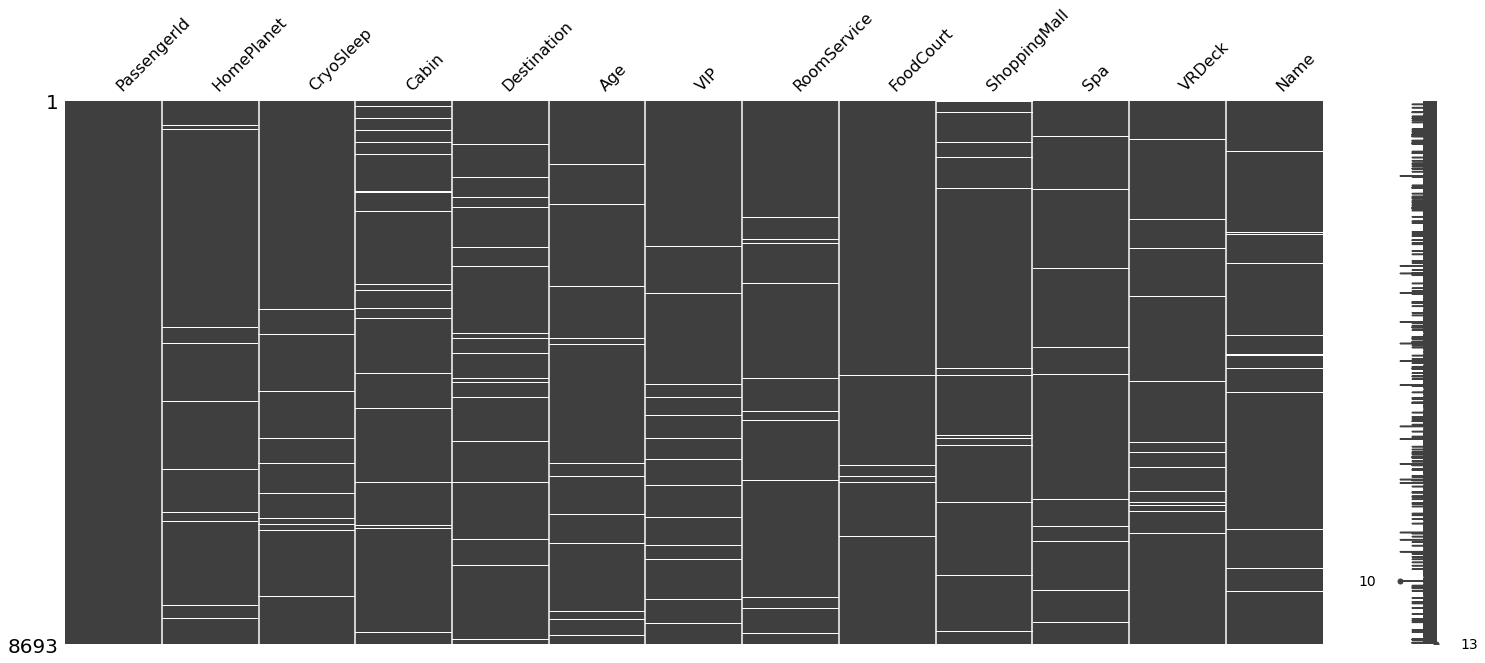

In [10]:
##  checking the missing values in the features of the data
print(X.isnull().sum())
print()

## watching missing values in the matrix format
import missingno as msgn

msgn.matrix(X)

**There are some missing values in each of the feature. So, need to work on that.**

In [11]:
## checking the unique values in the categorical features

for index, feature in enumerate(cat_feat):
    print(f"The unique values in the feature {feature} are {X[feature].unique()} (Total of {X[feature].nunique()}).\n")

The unique values in the feature PassengerId are ['0001_01' '0002_01' '0003_01' ... '9279_01' '9280_01' '9280_02'] (Total of 8693).

The unique values in the feature HomePlanet are ['Europa' 'Earth' 'Mars' nan] (Total of 3).

The unique values in the feature CryoSleep are [False True nan] (Total of 2).

The unique values in the feature Cabin are ['B/0/P' 'F/0/S' 'A/0/S' ... 'G/1499/S' 'G/1500/S' 'E/608/S'] (Total of 6560).

The unique values in the feature Destination are ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan] (Total of 3).

The unique values in the feature VIP are [False True nan] (Total of 2).

The unique values in the feature Name are ['Maham Ofracculy' 'Juanna Vines' 'Altark Susent' ... 'Fayey Connon'
 'Celeon Hontichre' 'Propsh Hontichre'] (Total of 8473).



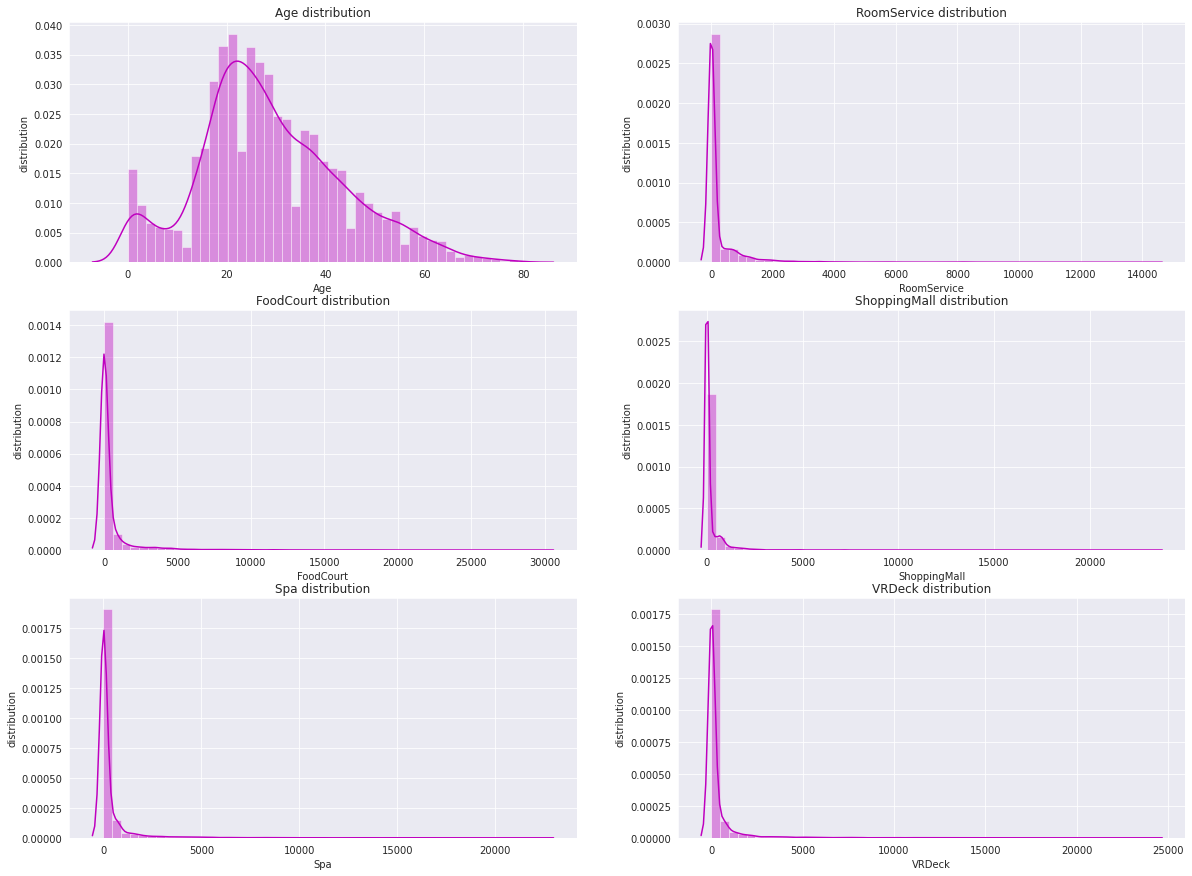

In [12]:
## checking the distribution of numberical features

sns.set_style('darkgrid')
plt.figure(figsize=(20,15))
for index,feature in enumerate(num_feat):
    plt.subplot(3,2,index+1)
    sns.distplot(X[feature],kde=True,color='m')
    plt.xlabel(feature)
    plt.ylabel("distribution")
    plt.title(f"{feature} distribution")

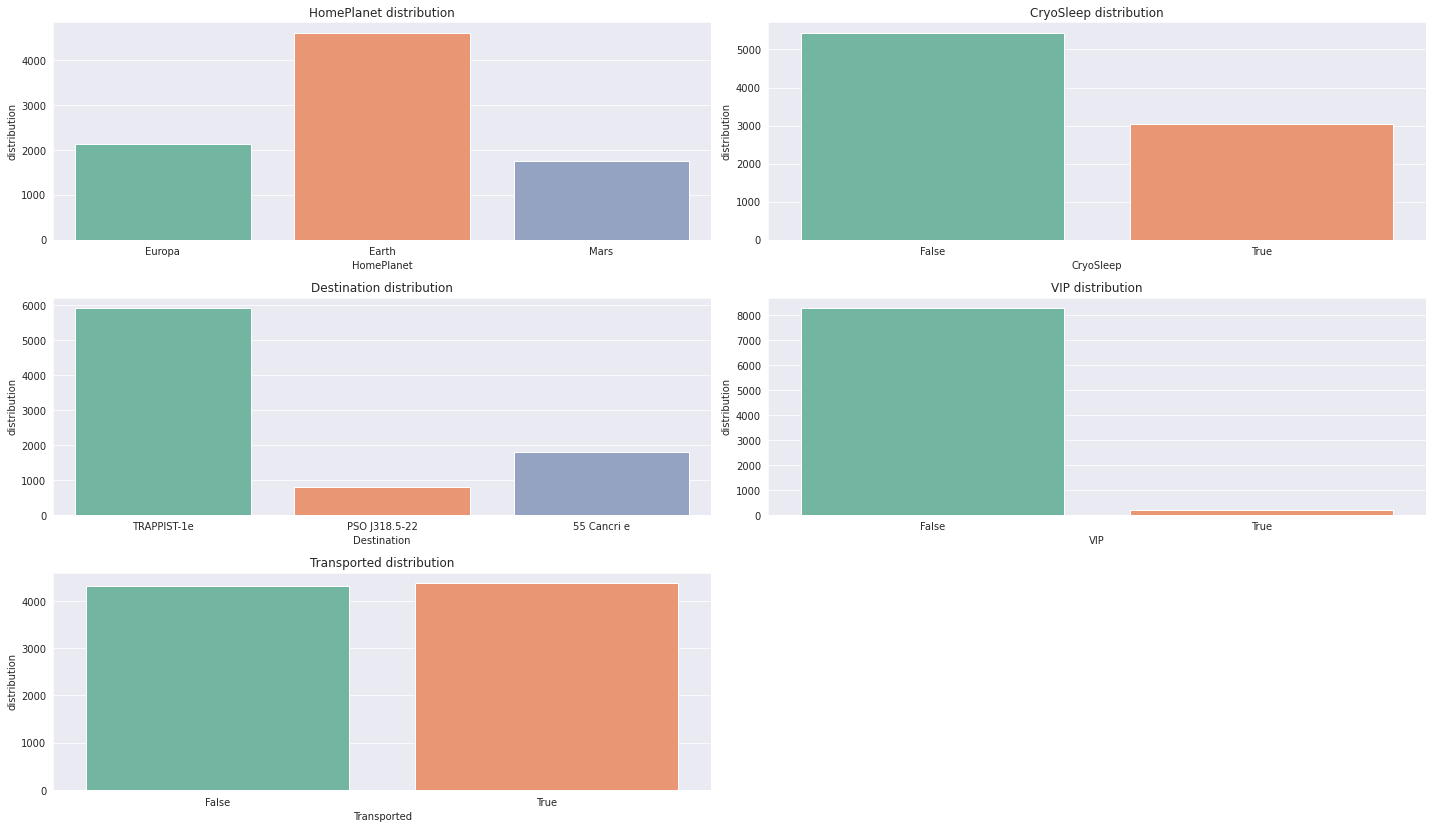

In [13]:
## checking the distribution of categorical features

sns.set_style('darkgrid')
plt.figure(figsize=(20,15))
for index, feature in enumerate(['HomePlanet', 'CryoSleep','Destination', 'VIP','Transported']):
    plt.subplot(4,2,index+1)
    sns.countplot(x=feature,data=df,palette='Set2')
    plt.xlabel(feature)
    plt.ylabel("distribution")
    plt.title(f"{feature} distribution")
plt.tight_layout()

<AxesSubplot:>

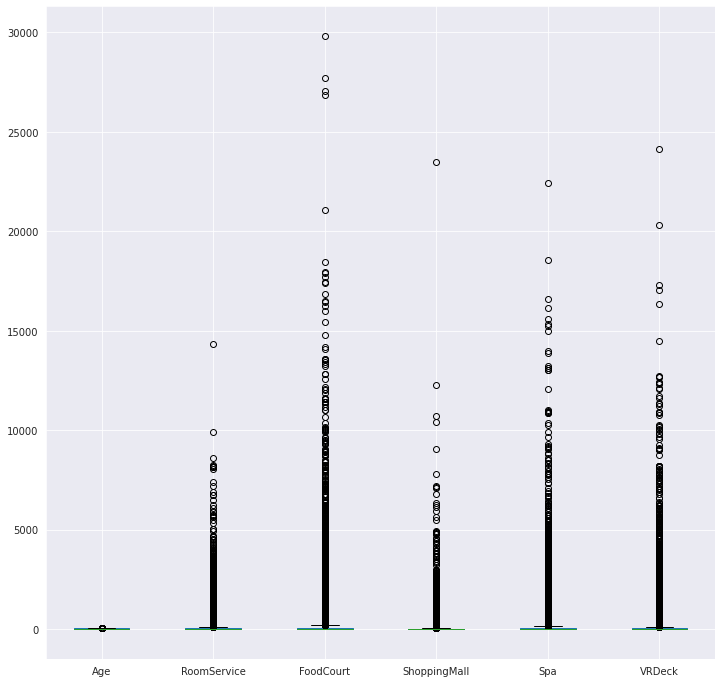

In [14]:
## checking if the numerical features contains any outliers using a boxplot

plt.figure(figsize=(12,12))
X[num_feat].boxplot()

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class Initial_Preprocess(BaseEstimator, TransformerMixin):
    
    def __init__(self,list_of_feature_names = ['PassengerId', 'Name', 'Cabin']): 
        self.list_of_feature_names = list_of_feature_names
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        ## creating new Cabin feature using olf Cabin feature
        print("Modifying the feature named 'Cabin'...")
        X['Cabin_info'] = X['Cabin'].map(lambda x: str(x).split('/')[0] + str(x).split('/')[-1])
        
        ## Removing unnecessary features
        print("Removing unnecessary features...")
        X.drop(columns = self.list_of_feature_names, axis=1,inplace=True)
        
        ## Taking care of outliers
        print("Taking care of outliers...")
        quantiles = X[num_feat].quantile(np.arange(0,1,0.25)).T
        quantiles = quantiles.rename(columns={0.25:'Q1', 0.50: 'Q2', 0.75:'Q3'})
        
        quantiles['IQR'] = quantiles['Q3'] - quantiles['Q1']
        quantiles['Lower_Limit'] = quantiles['Q1'] - 1.5*quantiles['IQR']
        quantiles['Upper_Limit'] = quantiles['Q3'] + 1.5*quantiles['IQR']
        
        for feature in num_feat:
            X[feature] = np.where((X[feature] < quantiles.loc[feature,'Lower_Limit']) | (X[feature] > quantiles.loc[feature,'Upper_Limit']) & (X[feature] is not np.nan), X[feature].median(), X[feature])
        
        return X

In [16]:
from sklearn.pipeline import Pipeline

initial_preprocess_pipe = Pipeline(steps=[
    ('inital_preprocess', Initial_Preprocess())
])

In [17]:
import pickle
with open('/kaggle/working/initial_preprocess_pipeline.pkl', 'wb') as f:
    pickle.dump(initial_preprocess_pipe, f)

In [18]:
processed_data = initial_preprocess_pipe.fit_transform(X)

Modifying the feature named 'Cabin'...
Removing unnecessary features...
Taking care of outliers...


In [19]:
processed_data

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin_info
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,BP
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,0.0,44.0,FS
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,0.0,0.0,0.0,49.0,AS
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,0.0,0.0,0.0,0.0,AS
4,Earth,False,TRAPPIST-1e,16.0,False,0.0,70.0,0.0,0.0,2.0,FS
...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,0.0,0.0,0.0,74.0,AP
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,GS
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,1.0,0.0,GS
8691,Europa,False,55 Cancri e,32.0,False,0.0,0.0,0.0,0.0,0.0,ES


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

cat_pipeline = Pipeline([
    ('cat_missing_fill1',SimpleImputer(strategy='most_frequent')),
    ('cat_encode', OneHotEncoder(handle_unknown='ignore')),
    ('cat_missing_fill2',SimpleImputer(strategy='most_frequent'))
])

num_pipeline = Pipeline([
    ('num_missing_fill',SimpleImputer(strategy='median')),
    ('num_std_scaler',StandardScaler())
])

preprocess_pipeline = ColumnTransformer([
    ('cat_preprocess',cat_pipeline,['HomePlanet', 'CryoSleep','Destination', 'VIP','Cabin_info']),
    ('num_preprocess',num_pipeline,['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'])
], remainder='passthrough')

In [21]:
import pickle
with open('/kaggle/working/preprocess_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocess_pipeline, f)

In [22]:
processed_data = preprocess_pipeline.fit_transform(processed_data)

In [23]:
processed_data[0].shape

(33,)

In [24]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=(33,)))
model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(200,activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(2,activation='softmax'))

2022-11-24 13:19:51.622378: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-24 13:19:51.623340: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-24 13:19:51.634199: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-24 13:19:51.635042: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-24 13:19:51.635865: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

In [25]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 33)                0         
_________________________________________________________________
dense (Dense)                (None, 300)               10200     
_________________________________________________________________
dense_1 (Dense)              (None, 200)               60200     
_________________________________________________________________
dense_2 (Dense)              (None, 100)               20100     
_________________________________________________________________
dense_3 (Dense)              (None, 2)                 202       
Total params: 90,702
Trainable params: 90,702
Non-trainable params: 0
_________________________________________________________________


In [26]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [27]:
model.fit(processed_data,y,epochs=50)

2022-11-24 13:19:53.802520: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/50
272/272 [==============================] - 1s 2ms/step - loss: 0.5336 - accuracy: 0.7262
Epoch 2/50
272/272 [==============================] - 1s 2ms/step - loss: 0.5067 - accuracy: 0.7409
Epoch 3/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4979 - accuracy: 0.7484
Epoch 4/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4935 - accuracy: 0.7492
Epoch 5/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4902 - accuracy: 0.7495
Epoch 6/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4874 - accuracy: 0.7519
Epoch 7/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4843 - accuracy: 0.7543
Epoch 8/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4823 - accuracy: 0.7554
Epoch 9/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4801 - accuracy: 0.7562
Epoch 10/50
272/272 [==============================] - 1s 2ms/step - loss: 0.4770 - accuracy: 0.7559

In [28]:
## importing test data
test = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')

In [29]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [30]:
## initial preprocessing of test data
processed_test = initial_preprocess_pipe.transform(test)
processed_test = preprocess_pipeline.transform(processed_test)

Modifying the feature named 'Cabin'...
Removing unnecessary features...
Taking care of outliers...


In [31]:
predictions = model.predict(processed_test)

In [32]:
predictions

array([[2.7783418e-01, 7.2216582e-01],
       [7.8617370e-01, 2.1382628e-01],
       [1.5032223e-09, 1.0000000e+00],
       ...,
       [6.4081476e-08, 9.9999988e-01],
       [6.3769817e-01, 3.6230186e-01],
       [4.4234183e-01, 5.5765814e-01]], dtype=float32)

In [33]:
classes = ['False','True']

y_pred = np.argmax(predictions, axis=1)
final_predictions = np.array(classes)[y_pred]

In [34]:
final_predictions

array(['True', 'False', 'True', ..., 'True', 'False', 'True'], dtype='<U5')

In [36]:
submission = pd.DataFrame()
test = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
submission['PassengerId'] = test['PassengerId']
submission['Transported'] = final_predictions

submission.to_csv('/kaggle/working/submission.csv', index=False)